# Position QA — Spot Check

Compare **trained** vs **untrained** Qwen3-VL-2B-Instruct on spatial reasoning:
given a game screenshot, answer questions like "Is the gold to the left or right of you?"

- **Trained**: checkpoint-28000 (merged full model)
- **Untrained**: base Qwen3-VL-2B-Instruct from HuggingFace

In [1]:
import sys
sys.path.insert(0, "..")

import random
import torch
from transformers import AutoProcessor

try:
    from transformers import AutoModelForImageTextToText as AutoModelForVision2Seq
except ImportError:
    from transformers import AutoModelForVision2Seq

CHECKPOINT_DIR = "../outputs/position_qa_dpo/merged_checkpoint_28000"
BASE_MODEL = "Qwen/Qwen3-VL-2B-Instruct"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
random.seed(42)

In [2]:
# Generate test samples using the same PositionQAGenerator as training
from src.data.position_qa_generator import PositionQAGenerator

generator = PositionQAGenerator(cross_axis_negative_prob=0.0)  # no cross-axis for cleaner eval
test_samples = generator.generate_batch(12)  # 12 examples
print(f"Generated {len(test_samples)} test samples")

/venv/main/lib/python3.12/site-packages/pygame/pkgdata.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_stream, resource_exists


pygame 2.6.1 (SDL 2.28.4, Python 3.12.12)
Hello from the pygame community. https://www.pygame.org/contribute.html


config.json:   0%|          | 0.00/726 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/11.4M [00:00<?, ?B/s]

Generated 12 test samples


In [3]:
# Load processor (from checkpoint so chat format matches)
processor = AutoProcessor.from_pretrained(CHECKPOINT_DIR, trust_remote_code=True)

In [4]:
# Load base model (untrained)
base_model = AutoModelForVision2Seq.from_pretrained(
    BASE_MODEL,
    trust_remote_code=True,
    torch_dtype=torch.bfloat16,
    device_map="auto",
)
base_model.eval()
print("Base model loaded")

config.json: 0.00B [00:00, ?B/s]

`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors:   0%|          | 0.00/4.26G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/625 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/269 [00:00<?, ?B/s]

Base model loaded


In [5]:
# Load trained model (merged checkpoint)
trained_model = AutoModelForVision2Seq.from_pretrained(
    CHECKPOINT_DIR,
    trust_remote_code=True,
    torch_dtype=torch.bfloat16,
    device_map="auto",
)
trained_model.eval()
print("Trained model loaded from", CHECKPOINT_DIR)

Loading weights:   0%|          | 0/625 [00:00<?, ?it/s]

Trained model loaded from ../outputs/position_qa_dpo/merged_checkpoint_28000


In [6]:
def generate_response(model, processor, image, prompt, max_new_tokens=32):
    """Generate response for image + prompt. Uses same format as trainer."""
    messages = [
        {"role": "user", "content": [{"type": "image"}, {"type": "text", "text": prompt}]}
    ]
    prompt_text = processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    inputs = processor(text=[prompt_text], images=[image], return_tensors="pt")
    inputs = inputs.to(model.device)
    with torch.no_grad():
        out = model.generate(**inputs, max_new_tokens=max_new_tokens, do_sample=False)
    prompt_len = inputs["input_ids"].shape[1]
    generated = out[0][prompt_len:]
    return processor.decode(generated, skip_special_tokens=True, clean_up_tokenization_spaces=True)

In [7]:
def is_correct(response, chosen):
    """Check if response is semantically correct (contains the key direction)."""
    r = response.strip().lower()
    c = chosen.strip().lower()
    # Key direction words
    if "left" in c or "right" in c:
        return ("left" in r and "left" in c) or ("right" in r and "right" in c)
    if "up" in c or "above" in c:
        return "up" in r or "above" in r
    if "down" in c or "below" in c:
        return "down" in r or "below" in r
    return False

## Run inference and compare

In [8]:
results = []
for i, sample in enumerate(test_samples):
    img = sample["image"]
    prompt = sample["prompt"]
    chosen = sample["chosen"]
    
    base_out = generate_response(base_model, processor, img, prompt)
    trained_out = generate_response(trained_model, processor, img, prompt)
    
    base_ok = is_correct(base_out, chosen)
    trained_ok = is_correct(trained_out, chosen)
    
    results.append({
        "prompt": prompt,
        "chosen": chosen,
        "base_out": base_out,
        "trained_out": trained_out,
        "base_correct": base_ok,
        "trained_correct": trained_ok,
    })

base_acc = sum(r["base_correct"] for r in results) / len(results)
trained_acc = sum(r["trained_correct"] for r in results) / len(results)
print(f"Base model accuracy:   {base_acc:.1%} ({sum(r['base_correct'] for r in results)}/{len(results)})")
print(f"Trained model accuracy: {trained_acc:.1%} ({sum(r['trained_correct'] for r in results)}/{len(results)})")

The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


Base model accuracy:   41.7% (5/12)
Trained model accuracy: 100.0% (12/12)


## Side-by-side examples

Example 1
Prompt:  Please tell me whether you are up or down from the gold.
Correct: The agent is above the gold.


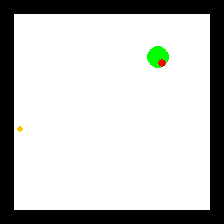

  Base:    Based on the image provided, we can analyze the positions of the objects.

- The gold object is a small, yellow dot located on the far left side of ✗
  Trained: up ✓

Example 2
Prompt:  On which side is the gold?
Correct: It's on the left.


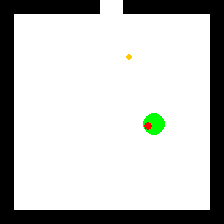

  Base:    Based on the image provided, the gold-colored dot is located on the **top** side of the white square. ✗
  Trained: left ✓

Example 3
Prompt:  Is the agent above or below the gold?
Correct: I'm below it.


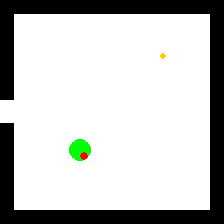

  Base:    Based on the image provided, we can analyze the positions of the two objects.

- There is a green object, which appears to be the agent, located in ✗
  Trained: below ✓

Example 4
Prompt:  Please tell me which side you are relative to the gold.
Correct: Right


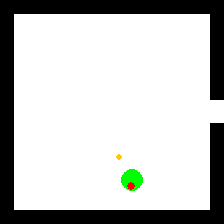

  Base:    Based on the image provided, I can analyze the positions of the objects.

- The gold object is a small, yellow diamond-shaped piece located in the upper-left ✗
  Trained: right ✓

Example 5
Prompt:  On which side of the gold are you?
Correct: The agent is on the left.


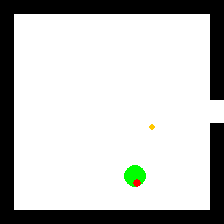

  Base:    Based on the image provided, we can analyze the positions of the objects.

- There is a small, yellow, diamond-shaped object, which we can identify as ✗
  Trained: left
 ✓

Example 6
Prompt:  Which side is the gold on?
Correct: The agent is on the right.


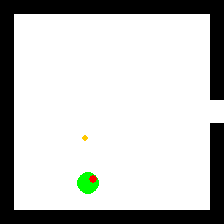

  Base:    Based on the image provided, the gold-colored dot is on the **top** side.

Here is a breakdown of the image:
- The image is a simple ✗
  Trained: right ✓

Example 7
Prompt:  Please tell me whether you are right or left of the gold.
Correct: Right


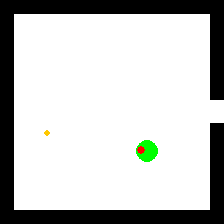

  Base:    Based on the image provided, I am to the right of the gold.

- The gold is the small, yellow dot located on the far left side of the ✓
  Trained: right
You are on the right side of the gold. ✓

Example 8
Prompt:  Which side is the gold on?
Correct: Right


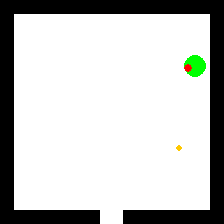

  Base:    Based on the image provided, the gold-colored dot is on the **bottom right** side. ✓
  Trained: the right ✓

Example 9
Prompt:  Which side is it on?
Correct: Go right.


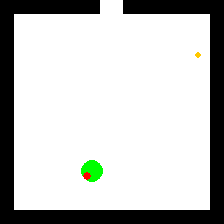

  Base:    Based on the image provided, the object in question is a small, yellow dot located in the upper right portion of the white space. The object is a small ✓
  Trained:  right ✓

Example 10
Prompt:  Do you need to go up or down to get the gold?
Correct: It's above me.


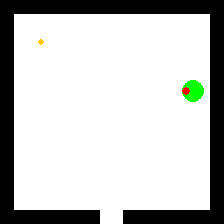

  Base:    Based on the image provided, there is a gold-colored dot located in the upper-left corner of the white area. The green dot is in the lower-right corner ✓
  Trained: up ✓

Example 11
Prompt:  Is the agent above or below the gold?
Correct: The agent is below the gold.


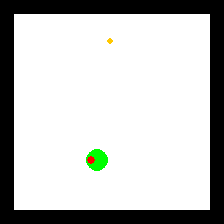

  Base:    Based on the image provided, we can analyze the positions of the two agents.

- The green agent is located at the bottom of the image.
- The gold ✗
  Trained: below ✓

Example 12
Prompt:  Please tell me whether you are right or left of the gold.
Correct: The agent is on the left.


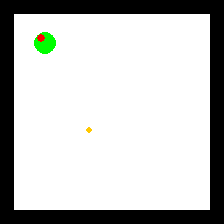

  Base:    Based on the image provided, the gold object is located in the lower center of the white square. The green object is in the upper left corner.

Therefore, ✓
  Trained: left ✓



In [9]:
from IPython.display import display

for i, r in enumerate(results):
    print("=" * 70)
    print(f"Example {i+1}")
    print(f"Prompt:  {r['prompt']}")
    print(f"Correct: {r['chosen']}")
    display(test_samples[i]["image"])
    print(f"  Base:    {r['base_out']} {'✓' if r['base_correct'] else '✗'}")
    print(f"  Trained: {r['trained_out']} {'✓' if r['trained_correct'] else '✗'}")
    print()

In [10]:
# Text-only comparison (use if image display fails)
for i, r in enumerate(results):
    print("=" * 70)
    print(f"Example {i+1} | Prompt: {r['prompt']} | Correct: {r['chosen']}")
    print(f"  Base: {r['base_out']} {'✓' if r['base_correct'] else '✗'}")
    print(f"  Trained: {r['trained_out']} {'✓' if r['trained_correct'] else '✗'}")

Example 1 | Prompt: Please tell me whether you are up or down from the gold. | Correct: The agent is above the gold.
  Base: Based on the image provided, we can analyze the positions of the objects.

- The gold object is a small, yellow dot located on the far left side of ✗
  Trained: up ✓
Example 2 | Prompt: On which side is the gold? | Correct: It's on the left.
  Base: Based on the image provided, the gold-colored dot is located on the **top** side of the white square. ✗
  Trained: left ✓
Example 3 | Prompt: Is the agent above or below the gold? | Correct: I'm below it.
  Base: Based on the image provided, we can analyze the positions of the two objects.

- There is a green object, which appears to be the agent, located in ✗
  Trained: below ✓
Example 4 | Prompt: Please tell me which side you are relative to the gold. | Correct: Right
  Base: Based on the image provided, I can analyze the positions of the objects.

- The gold object is a small, yellow diamond-shaped piece located in